### Importing Packages

In [94]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.utils.data import Subset

import matplotlib.pyplot as plt
import numpy as np

from tqdm import tqdm 

import random

import scipy
from scipy.optimize import linear_sum_assignment

import copy

import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

### Seed

In [32]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

### Importing Data

In [33]:
# Transform images to tensors
transform = transforms.ToTensor()

# Load training dataset
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Load test dataset
test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

### Helper Functions

In [34]:
def filter_data(dataset, allowed_digits):

    """
    The function filter_data generates a subset of the given MNIST dataset consisting of all and only all of
    the images of digits in allowed_digits

    Args:
        dataset: MNIST dataset 
        allowed_digits: list of digits to look for in dataset

    Returns:
        filtered_dataset: MNIST subset of dataset consisting of all and only all digits in allowed_digits
    """

    labels = dataset.targets

    mask = torch.zeros_like(labels, dtype=torch.bool)

    for digit in allowed_digits:

        mask |= (labels == digit)

    indices = torch.where(mask)[0]

    filtered_dataset = Subset(dataset, indices)

    return filtered_dataset

In [35]:
def train_model(model, training_data_loader, testing_data_loader, 
                training_digit_group, num_epochs, 
                stabilize, old_pca_components, λ
               ):

    """
    The function train_model trains the given model on the given MNIST digits, using the given relevant 
    subset of the MNIST dataset, for the given number of epochs. At the end of every epoch 1) the model is 
    tested on the entire MNIST testing dataset and a confusion matrix is developed, and 2) the hidden
    representation of the all digits the model was trained on (the 64-dimensional output vector of the last
    hidden layer in the neural network) is retrieved, and the given number of principal components are computed.

    Args:
        model: the neural network you wish to train
        training_data_loader: DataLoader of the subset of the MNIST training dataset corresponding to training_digit_group
        testing_data_loader: List of DataLoaders of the properly sorted MNIST testing dataset
        training_digit_group: list of digits you wish to train the model on
        num_epochs: positive integer number of tiems you wish for the model to be trained on training_data_loader
        stabilize: bool of whether stabilize the network with learning constraints
        old_pca_componetns: array of old pca components you are use to constrain learning
        λ: float, inverse plasticity hyperparameter

    Returns:
        model: trained neural network
        cm_epoch_set: list of confusion matrices computed after each epoch of training
        pca_epoch_set: list of PCAs computed after each epoch of training
        scaler_epoch_set: list of scalers cfit after each epoch after training
    """

    base_loss_function = nn.CrossEntropyLoss()
    penalty_function = pca_drift_penalty
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    cm_epoch_set = []
    pca_epoch_set = []
    scaler_epoch_set = []

    for epoch in tqdm(range(num_epochs)):

        ############################
        #### TRAINING
        ############################

        model.train()

        total_loss = 0.0
        
        for inputs, labels in training_data_loader:

            optimizer.zero_grad()

            outputs = model(inputs)

            loss = base_loss_function(outputs, labels) + λ*penalty_function(stabilize, model, old_pca_components, inputs)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Total Training Loss: {total_loss:.4f}")

        ############################
        #### VALIDATING
        ############################

        model.eval()

        with torch.no_grad():
            
            cm = get_cm(model, testing_data_loader)
            pca, scaler = get_pca(model, testing_data_loader, training_digit_group)

            cm_epoch_set.append(cm)
            pca_epoch_set.append(pca)
            scaler_epoch_set.append(scaler)

    return model, cm_epoch_set, pca_epoch_set, scaler_epoch_set

In [36]:
def make_cgm_colormap(vmin=-2, vmax=12, neutral_low=0, neutral_high=3):
    """
    Three-zone colormap for standardised CGM z-scores.
 
    Zone 1  [vmin,         neutral_low)   cool blue gradient
                Overlap is *below* the random mean — the PC pair is more
                orthogonal than two random unit vectors would be on average.
                Note: the physical minimum is z ≈ -1.33  (when |u·v| = 0),
                so the deep blue end of this zone is unreachable.
 
    Zone 2  [neutral_low,  neutral_high]  flat grey
                Overlap is statistically indistinguishable from chance.
                The flat colour makes the noise band immediately obvious
                regardless of the value within it.
 
    Zone 3  (neutral_high, vmax]          warm gradient (yellow → red)
                Overlap significantly exceeds the random baseline —
                evidence of genuine shared structure between the two PCAs.
 
    The hard colour breaks at neutral_low and neutral_high are created by
    repeating each boundary position in the colour list with two different
    colours; LinearSegmentedColormap treats this as a step discontinuity.
 
    Args:
        vmin, vmax      : z-score range for the colour scale
        neutral_low     : lower boundary of the grey (noise) band; default 0
        neutral_high    : upper boundary of the grey (noise) band; default 3
 
    Returns:
        cmap (LinearSegmentedColormap)
        norm (Normalize)
    """
    def p(z):
        return (z - vmin) / (vmax - vmin)
 
    cmap = LinearSegmentedColormap.from_list(
        'cgm_zones',
        [
            (p(vmin),          '#2166AC'),  # deep blue  (most orthogonal)
            (p(neutral_low),   '#D1E5F0'),  # pale blue  (approaching random mean)
            (p(neutral_low),   '#B0B0B0'),  # ← hard break: grey noise band begins
            (p(neutral_high),  '#B0B0B0'),  # grey noise band ends
            (p(neutral_high),  '#FFFFCC'),  # ← hard break: warm signal zone begins
            (p(6),             '#FD8D3C'),  # orange
            (p(9),             '#D7191C'),  # red
            (p(vmax),          '#67000D'),  # dark red   (strongest alignment)
        ],
        N=512
    )
 
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
 
    return cmap, norm

### get_cm(model, testing_data_loader)

Builds a confusion matrix for the given model using the testing data from testing_data_loader. Predictions are made by taken as the highest probability logit in the output of the mode:

$$prediction = \underset{i\in[0, 9]}{max}\hspace{0.1cm}l_{i}$$

$$\mathbf{N} = \underset{predicted \hspace{0.1cm}labels \hspace{0.1cm}\times\hspace{0.1cm} true \hspace{0.1cm}labels}{\begin{bmatrix} n_{1,1} & n_{1,2} & \cdots & n_{1, 10} \\
n_{2,1} & n_{2,2} & \cdots & n_{2, 10} \\ 
\vdots & \vdots & \ddots & \vdots \\
n_{10,1} & n_{10,2} & \cdots & n_{10, 10}\end{bmatrix}}$$

    Args:
        model                : neural network type; trained neural network
        testing_data_loader  : list type; list of DataLoaders of properly sorted MNIST testing images

    Returns:
        cm                   : array type; confusion matrix visualizing how the model predicts (rows) images of a specific true label (columns)

In [37]:
def get_cm(model, testing_data_loader):

    cm = np.zeros((10, 10))

    for true_label in range(10):

        for inputs, labels in testing_data_loader[true_label]:

            outputs = model(inputs)

            predicted_labels = torch.argmax(outputs, dim=1).numpy()

            np.add.at(cm, (predicted_labels, true_label), 1)

    return cm

### get_pca(model, testing_data_loader, digit_group)

Performs a principal component analysis (PCA) on the hidden-state representation of a group of digits digit_group within the neural network model. PCA is done by computing eigenvalue-eigenvector pairs of the feature covariance matrix (covariance matrix is computed as feature covariances of feature-standardized data):

$$ \{\lambda_i, \hat{u}_i\}: \hspace{1cm} \mathbf{C}\hat{u}=\lambda_i\hat{u}_i$$

$$\underset{num \hspace{0.1cm}features\hspace{0.1cm}\times num \hspace{0.1cm}features}{\mathbf{C}}=\underset{num\hspace{0.1cm}features\hspace{0.1cm}\times batch\hspace{0.1cm}size}{\mathbf{Z}^T}\hspace{0.3cm}\underset{batch \hspace{0.1cm}size\hspace{0.1cm}\times num \hspace{0.1cm}features}{\mathbf{Z}}$$

    Args:
        model: neural network type; the neural network whose hidden representation we are probing
        testing_data_loader: DataLoader type; the properly sorted testing data used to evaluate model
        digit_group: list type; list of digits we are probing for the hidden representation of

    Returns:
        pca: pca type; pca fit to the standardized hidden representation data
        scaler: ? type; scaler used to fit the pca 

In [38]:
def get_pca(model, testing_data_loader, digit_group):
    
    all_batches = []                                             # shape: null
 
    for digit in digit_group:
        
        for inputs, labels in testing_data_loader[digit]:
            
            hidden_outputs = model.hidden(inputs).numpy()        # shape: (batch_size, hidden_size)
       
            all_batches.append(hidden_outputs)                   
 
    data = np.concatenate(all_batches, axis=0)                   # shape: (num_batchs X batch_size, hidden_size)
 
    scaler = StandardScaler()
    standardized_data = scaler.fit_transform(data)
 
    pca = PCA()
    pca.fit(standardized_data)                                   # shape: (hidden_size, hidden_size) (since hidden_size < num_batchs X batch_size)
 
    return pca, scaler

### pca_drift_penalty(stabilize, model, old_pca_components, inputs)

This function penalizes how much of the current hidden representation of the inputs lies within the span of some subset of the old principal components. The penalty is computed according to the following rule:


$$\underset{(batch \hspace{0.1cm}size\hspace{0.1cm}\times\hspace{0.1cm} hidden\hspace{0.1cm} size)}{\mathbf{h}_i} = \underset{(batch \hspace{0.1cm}size\hspace{0.1cm}\times\hspace{0.1cm} hidden\hspace{0.1cm} size)}{\mathbf{H}_i}\hspace{0.3cm}\underset{(hidden\hspace{0.1cm} size \hspace{0.1cm}\times\hspace{0.1cm} pca\hspace{0.1cm} size)}{\mathbf{P^T}}\hspace{0.3cm}\underset{(pca\hspace{0.1cm} size\hspace{0.1cm}\times\hspace{0.1cm} hidden\hspace{0.1cm} size)}{\mathbf{P}}$$

$$\underset{(batch\hspace{0.1cm} size\hspace{0.1cm}\times\hspace{0.1cm} hidden\hspace{0.1cm} size)}{\mathbf{R}_i} = \underset{(batch\hspace{0.1cm} size\hspace{0.1cm}\times\hspace{0.1cm} hidden\hspace{0.1cm} size)}{\mathbf{H}_i}-\underset{(batch\hspace{0.1cm} size\hspace{0.1cm}\times\hspace{0.1cm} hidden\hspace{0.1cm} size)}{\mathbf{h}_i}$$

$$\underset{1\times 1}{penalty} = \frac{1}{batch\hspace{0.1cm}size\hspace{0.1cm}\times\hspace{0.1cm}
hidden\hspace{0.1cm}size}\sum_{n=1}^{batch\hspace{0.1cm} size}\sum_{m=1}^{hidden\hspace{0.1cm} size}R_{nm}^2$$

    Args:
        stabilize                  : Boolean type; whether to compute non-trivial penalty
        model                      : Neural Network type; neural network being trained
        old_pca_components         : array type; subspace the hidden representation will be projected onto and reconstructed from
        inputs                     : tensor type; input data the neural network is being trained on

    Returns:
        penalty                    : float type; penalty (with auto-grad) to be added to loss function in neural network training
        

In [39]:
def pca_drift_penalty(stabilize, model, old_pca_components, inputs):
    
    if not stabilize:
        return torch.tensor(0.0)                       # shape: ()

    V = torch.tensor(
        old_pca_components,                            # shape: (pca_size, hidden_size)
        dtype=torch.float32
    )

    hidden_outputs = model.hidden(inputs)              # shape: (batch_size, hidden_size)

    projections   = hidden_outputs @ V.T               # shape: (batch_size, hidden_size) X (hidden_size, pca_size) = (batch_size, pca_size)
    reconstructions = projections @ V                  # shape: (batch_size, pca_size) X (pca_size, hidden_size) = (batch_size, hidden_size)

    residual = hidden_outputs - reconstructions        # shape: (batch, hidden_size)
    penalty  = torch.mean(residual ** 2)               # shape: ()

    return penalty

### monte_carlo_cgm(dim_subspace, dim_space, n_samples=100_000, seed=42)

Monte Carlo estimate (N = n_samples, from seed) of the mean and standard deviation of the cross-Gram-matrices two randomly sampled dim_subspace-dimensional orthonormal bases $\mathcal{U}, \mathcal{V}\in\mathbb{R}^{dim\hspace{0.1cm}space \hspace{0.1cm}\times\hspace{0.1cm} dim \hspace{0.1cm} subspace}$. The n_samples pairs of subspaces are drawn as a dim_space by dim_subspace array of dim_subspace samples from the dim_space dimensional standard normal distribution, $\mathcal{N}_{dim\hspace{0.1cm}space}(0, 1)$ and orthonormalized. 

Analytical Expressions (dim_subspace=1):

$$\mu_{|\hat{u}\cdot\hat{v}|} = \frac{\Gamma\left(\frac{d}{2}\right)}{\sqrt{\pi}\Gamma\left(\frac{d+1}{2}\right)}\overset{d=64}{\approx}0.100$$

$$\sigma_{|\hat{u}\cdot\hat{v}|} = \sqrt{\frac{1}{d}-\mu_{|\hat{u}\cdot\hat{v}|}^2}\overset{d=64}{\approx}0.075$$

    Args:
        dim_subspace          : int type; dimensionality of subspaces being drawn
        dim_space             : int type; dimensionality of the overall space embedding the subspaces
        n_samples             : int type; number of sample drawn for the Monte Carlo approximation
        seed                  : int type; seed number for repeatable stochastic results

    Returns:
        μ                     : float type; sample mean computed by Monte Carlo
        σ                     : float type; sample standard deviation computed by Monte Carlo

In [40]:
def monte_carlo_cgm(dim_subspace, dim_space, n_samples=100_000, seed=42):

    rng = np.random.default_rng(seed)
 
    U = rng.standard_normal((n_samples, dim_space, dim_subspace))          # shape: (n_samples, dim_space, dim_subspace)
    V = rng.standard_normal((n_samples, dim_space, dim_subspace))          # shape: (n_samples, dim_space, dim_subspace)

    U, _ = np.linalg.qr(U)                                                   # shape: (n_samples, dim_space, dim_subspace)
    V, _ = np.linalg.qr(V)                                                   # shape: (n_samples, dim_space, dim_subspace)

    cgm = np.abs(np.einsum("ndi, ndj -> nij", U, V))                             # shape: (n_samples, dim_subspace, dim_subspace)

 
    μ = np.mean(cgm)                      # shape: ()
    σ = np.std(cgm)                       # shape: ()  
 
    return μ, σ

In [41]:
def compute_random_baseline_gdist(dim_space, dim_subspace, n_samples=100_000, seed=42):

    rng = np.random.default_rng(seed)

    # Sample uniformly on the hypersphere via normalised Gaussians
    U = rng.standard_normal((n_samples, dim_space, dim_subspace)) 
    V = rng.standard_normal((n_samples, dim_space, dim_subspace))
    
    U, _ = np.linalg.qr(U) #(n_samples, dim_space, dim_subspace)
    V, _ = np.linalg.qr(V) #(n_samples, dim_space, dim_subspace)
    
    M = np.einsum("nij, nik->njk", U, V)
    sigma = np.linalg.svd(M, compute_uv=False)
    sigma = np.clip(sigma, -1, 1)

    pangles = np.arccos(sigma)

    gdist = np.linalg.norm(pangles, axis=1)

    return gdist.mean(axis=0), gdist.std(axis=0)

In [42]:
def get_all_activations(model, testing_data_loader, digit_group):

    all_a1, all_a2, all_a3, all_labels = [], [], [], []

    model.eval()

    with torch.no_grad():
    
        for digit in digit_group:

            for inputs, labels in testing_data_loader[digit]:

                a1 = model.forward1(inputs).numpy()
                a2 = model.forward2(inputs).numpy()
                a3 = model.forward3(inputs).numpy()

                all_a1.append(a1)
                all_a2.append(a2)
                all_a3.append(a3)
                all_labels.append(labels.numpy())


        all_a1 = np.concatenate(all_a1, axis=0)
        all_a2 = np.concatenate(all_a2, axis=0)
        all_a3 = np.concatenate(all_a3, axis=0)
        all_labels = np.concatenate(all_labels, axis=0)

        all_activations = np.concatenate([all_a1, all_a2, all_a3], axis=1)

    return all_activations, all_labels

In [43]:
def get_correlation(activations):

    return np.corrcoef(activations.T)

In [44]:
def get_cluster(corr_matrix, threshold=0.5):

    dist = 1 - np.clip(np.abs(corr_matrix), 0, 1)
    np.fill_diagonal(dist, 0)

    condensed = squareform(dist, checks=False)

    Z = linkage(condensed, method="average")
    cluster_labels = fcluster(Z, t=threshold, criterion="distance")

    return cluster_labels

In [46]:
def get_clugitcorr():
    pass

In [95]:
def plot_cms(cm_set):

    num_groups, num_epochs = len(cm_set), len(cm_set[0])

    fig, axes = plt.subplots(
                            nrows=num_epochs,
                            ncols=num_groups,
                            figsize=(4 * num_groups, 5 * num_epochs)
                            )

    
    axes = np.array(axes).reshape(num_epochs, num_groups)

    for m in range(num_groups):          
        for n in range(num_epochs):     

            ax = axes[n, m]
            cm = cm_set[m][n]

            im = ax.imshow(cm, cmap='Blues')

            # annotate cells
            for i in range(cm.shape[0]):
                for j in range(cm.shape[1]):
                    ax.text(
                        j, i,
                        str(int(cm[i, j])),
                        ha='center',
                        va='center',
                        color='black',
                        fontsize=8
                    )

            ax.set_title(f"Training Group {m+1}, Epoch {n+1}")

            ax.set_xlabel("True Label")
            ax.set_ylabel("Predicted Label")

    # One shared colorbar (important)
    fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02)

    plt.show()

    return

In [100]:
def plot_pcas(pca_set, μ_cgm, σ_cgm, diagonalize):

    ###########################################
    #### MAKING CGMS
    ###########################################
    
    num_groups, num_epochs = len(pca_set), len(pca_set[0])
    flattened_pca_set = np.reshape(pca_set, (-1))
    num_plots = len(flattened_pca_set)

    plot_set = []

    for i in range(num_plots):

        pca_A = flattened_pca_set[num_epochs-1].components_
        pca_B = flattened_pca_set[i].components_

        cgm_i = np.abs(pca_A @ pca_B.T)
        z_cgm_i = (cgm_i-μ_cgm)/σ_cgm

        if diagonalize:

            cost = 1 - z_cgm_i
            rows, cols = linear_sum_assignment(cost)
            dz_cgm_i = z_cgm_i[:, cols]
            plot_set.append(dz_cgm_i)

        else:

            plot_set.append(z_cgm_i)

    
    ###########################################
    #### MAKING PLOTS
    ###########################################

    cgm_cmap, cgm_norm = make_cgm_colormap(
                                            vmin=-2,
                                            vmax=12,
                                            neutral_low=-2,     
                                            neutral_high=4    
                                        )
 
    CGM_TICKS  = [-2, -1.3,         0,              2,        4,        6,        9,       12]
    CGM_LABELS = ['-2', '-1.3\n(min)', '0\n(mean)', '2', '4', '6', '9', '12']
    
    fig, axes = plt.subplots(
                            nrows=num_epochs,
                            ncols=num_groups,
                            figsize=(4 * num_groups, 5 * num_epochs)
                            )

    axes = np.array(axes).reshape(num_epochs, num_groups)

    for i in range(num_plots):

        g_earlier = i//num_epochs
        g_later = (i+1)//num_epochs
        e_earlier = i%num_epochs
        e_later = (i+1)%num_epochs

        ax = axes[e_earlier, g_earlier]

        z_cgm = plot_set[i]

        im = ax.imshow(z_cgm, cmap=cgm_cmap, norm=cgm_norm)

        ax.set_title(f"z-CGM of Training Group {g_earlier+1}, Epoch {e_earlier+1} \n on Training Group {0+1}, Epoch {num_epochs}")

        ax.set_xlabel(f"PCs of Training Group {g_earlier+1}, Epoch {e_earlier+1}")
        ax.set_ylabel(f"PCs of Training Group {0+1}, Epoch {num_epochs}")

    cbar = fig.colorbar(im, ax=axes, ticks=CGM_TICKS, fraction=0.02, pad=0.04)
    cbar.ax.set_yticklabels(CGM_LABELS)
    cbar.set_label("PC overlap (σ above random baseline)", rotation=270, labelpad=20)

    plt.show()
    
    return

### Training Data

In [47]:
training_digit_groups = [[0, 1, 2], [3, 4, 5], [6, 7, 8, 9]]

In [48]:
training_groups = []

In [49]:
num_training_groups= len(training_digit_groups)

for i in range(num_training_groups):

    training_digit_group = training_digit_groups[i]

    X = filter_data(train_dataset, training_digit_group)

    Y = DataLoader(X, batch_size=64, shuffle=True)

    training_groups.append(Y)

### Testing Data

In [50]:
testing_digit_groups = [[i] for i in range(10)]

In [51]:
testing_groups = []

In [52]:
num_testing_groups = len(testing_digit_groups)

for i in range(num_testing_groups):

    testing_digit_group = testing_digit_groups[i]

    X = filter_data(test_dataset, testing_digit_group)

    Y = DataLoader(X, batch_size=64, shuffle=True)

    testing_groups.append(Y)

In [53]:
for inputs, labels in training_groups[2]:
    print(inputs.shape, labels.shape)
    print(labels)
    break
for inputs, labels in testing_groups[9]:
    print(inputs.shape, labels.shape)
    print(labels)
    break

torch.Size([64, 1, 28, 28]) torch.Size([64])
tensor([8, 6, 8, 9, 6, 6, 7, 6, 7, 8, 9, 7, 9, 7, 6, 7, 9, 7, 7, 9, 6, 9, 7, 6,
        9, 9, 8, 7, 6, 7, 6, 7, 9, 6, 6, 6, 8, 9, 7, 8, 6, 9, 9, 6, 7, 7, 8, 7,
        9, 6, 9, 8, 8, 6, 6, 7, 8, 9, 8, 7, 8, 8, 9, 6])
torch.Size([64, 1, 28, 28]) torch.Size([64])
tensor([9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9,
        9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9,
        9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9])


### Data Info

In [54]:
total_num_training_images = 0
num_training_images = []

In [55]:
for i in range(num_training_groups):

    S = 0

    for inputs, labels in training_groups[i]:

        S += len(labels)

    num_training_images.append(S)

    print(f"Number of training images in group {i+1}: {num_training_images[i]}")

    total_num_training_images += S

print()
print(f"Total number of training images: {total_num_training_images}")

Number of training images in group 1: 18623
Number of training images in group 2: 17394
Number of training images in group 3: 23983

Total number of training images: 60000


In [56]:
total_num_testing_images = 0
num_testing_images = []

In [57]:
for i in range(num_testing_groups):

    S = 0

    for inputs, labels in testing_groups[i]:

        S += len(labels)

    num_testing_images.append(S)

    print(f"Number of testing images of {i}: {num_testing_images[i]}")

    total_num_testing_images += S

print()
print(f"Total number of testing images: {total_num_testing_images}")

Number of testing images of 0: 980
Number of testing images of 1: 1135
Number of testing images of 2: 1032
Number of testing images of 3: 1010
Number of testing images of 4: 982
Number of testing images of 5: 892
Number of testing images of 6: 958
Number of testing images of 7: 1028
Number of testing images of 8: 974
Number of testing images of 9: 1009

Total number of testing images: 10000


### Defining NN Architecure

In [58]:
class NeuralNetwork(nn.Module):

    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.relu = nn.ReLU()

        self.layer1 = nn.Linear(28*28, 128)
        self.layer2 = nn.Linear(128, 64)
        self.layer3 = nn.Linear(64, 10)

    def forward1(self, inputs):

        X = self.flatten(inputs)
        
        X = self.layer1(X)
        X = self.relu(X)

        return X

    def forward2(self, inputs):

        X = self.forward1(inputs)

        X = self.layer2(X)
        X = self.relu(X)

        return X
        

    def forward3(self, inputs):

        X = self.forward2(inputs)

        X = self.layer3(X)

        logits = X

        return logits

    def forward(self, inputs):

        X = self.forward3(inputs)

        logits = X

        return logits


    def hidden(self, inputs):

        hidden = self.forward2(inputs)

        return hidden

### Training 

In [59]:
n_epochs = 5
n_old_pca_components = 16

In [60]:
model = NeuralNetwork()

In [61]:
model_group_set = []

cm_group_set = []

pca_group_set = []

scaler_group_set = []

In [62]:
trained_model_A, trained_cm_epoch_set_A, trained_pca_epoch_set_A, trained_scaler_epoch_set_A = train_model(model, training_data_loader=training_groups[0], 
                                                                                                           testing_data_loader=testing_groups, training_digit_group=training_digit_groups[0], 
                                                                                                           num_epochs=n_epochs, 
                                                                                                           stabilize=False, old_pca_components=None, λ=100
                                                                                                          )

pca_A = trained_pca_epoch_set_A[-1]
pca_components_A = pca_A.components_[:n_old_pca_components]

model_group_set.append(copy.deepcopy(trained_model_A))
cm_group_set.append(trained_cm_epoch_set_A)
pca_group_set.append(trained_pca_epoch_set_A)
scaler_group_set.append(trained_scaler_epoch_set_A)

trained_model_B, trained_cm_epoch_set_B, trained_pca_epoch_set_B, trained_scaler_epoch_set_B = train_model(model, training_data_loader=training_groups[1], 
                                                                                                           testing_data_loader=testing_groups, training_digit_group=training_digit_groups[1], 
                                                                                                           num_epochs=n_epochs, 
                                                                                                           stabilize=False, old_pca_components=pca_components_A, λ=100
                                                                                                          )

pca_B = trained_pca_epoch_set_B[-1]
pca_components_B = pca_B.components_[:n_old_pca_components]

model_group_set.append(copy.deepcopy(trained_model_B))
cm_group_set.append(trained_cm_epoch_set_B)
pca_group_set.append(trained_pca_epoch_set_B)
scaler_group_set.append(trained_scaler_epoch_set_B)    

trained_model_C, trained_cm_epoch_set_C, trained_pca_epoch_set_C, trained_scaler_epoch_set_C = train_model(model, training_data_loader=training_groups[2], 
                                                                                                           testing_data_loader=testing_groups, training_digit_group=training_digit_groups[2], 
                                                                                                           num_epochs=n_epochs,
                                                                                                           stabilize=False, old_pca_components=pca_components_B, λ=100
                                                                                                          )

pca_C = trained_pca_epoch_set_C[-1]
pca_components_C = pca_C.components_[:n_old_pca_components]

model_group_set.append(copy.deepcopy(trained_model_C))
cm_group_set.append(trained_cm_epoch_set_C)
pca_group_set.append(trained_pca_epoch_set_C)
scaler_group_set.append(trained_scaler_epoch_set_C)    

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1, Total Training Loss: 44.9167


 20%|██        | 1/5 [00:05<00:21,  5.31s/it]

Epoch 2, Total Training Loss: 9.6273


 40%|████      | 2/5 [00:10<00:15,  5.05s/it]

...

 60%|██████    | 3/5 [00:18<00:12,  6.11s/it]

Epoch 4, Total Training Loss: 13.3881


 80%|████████  | 4/5 [00:24<00:06,  6.14s/it]

Epoch 5, Total Training Loss: 10.3644


100%|██████████| 5/5 [00:30<00:00,  6.13s/it]


In [63]:
for i in range(num_training_groups):

    print(model_group_set[i] is model)

False
False
False


### Confusion Matrix

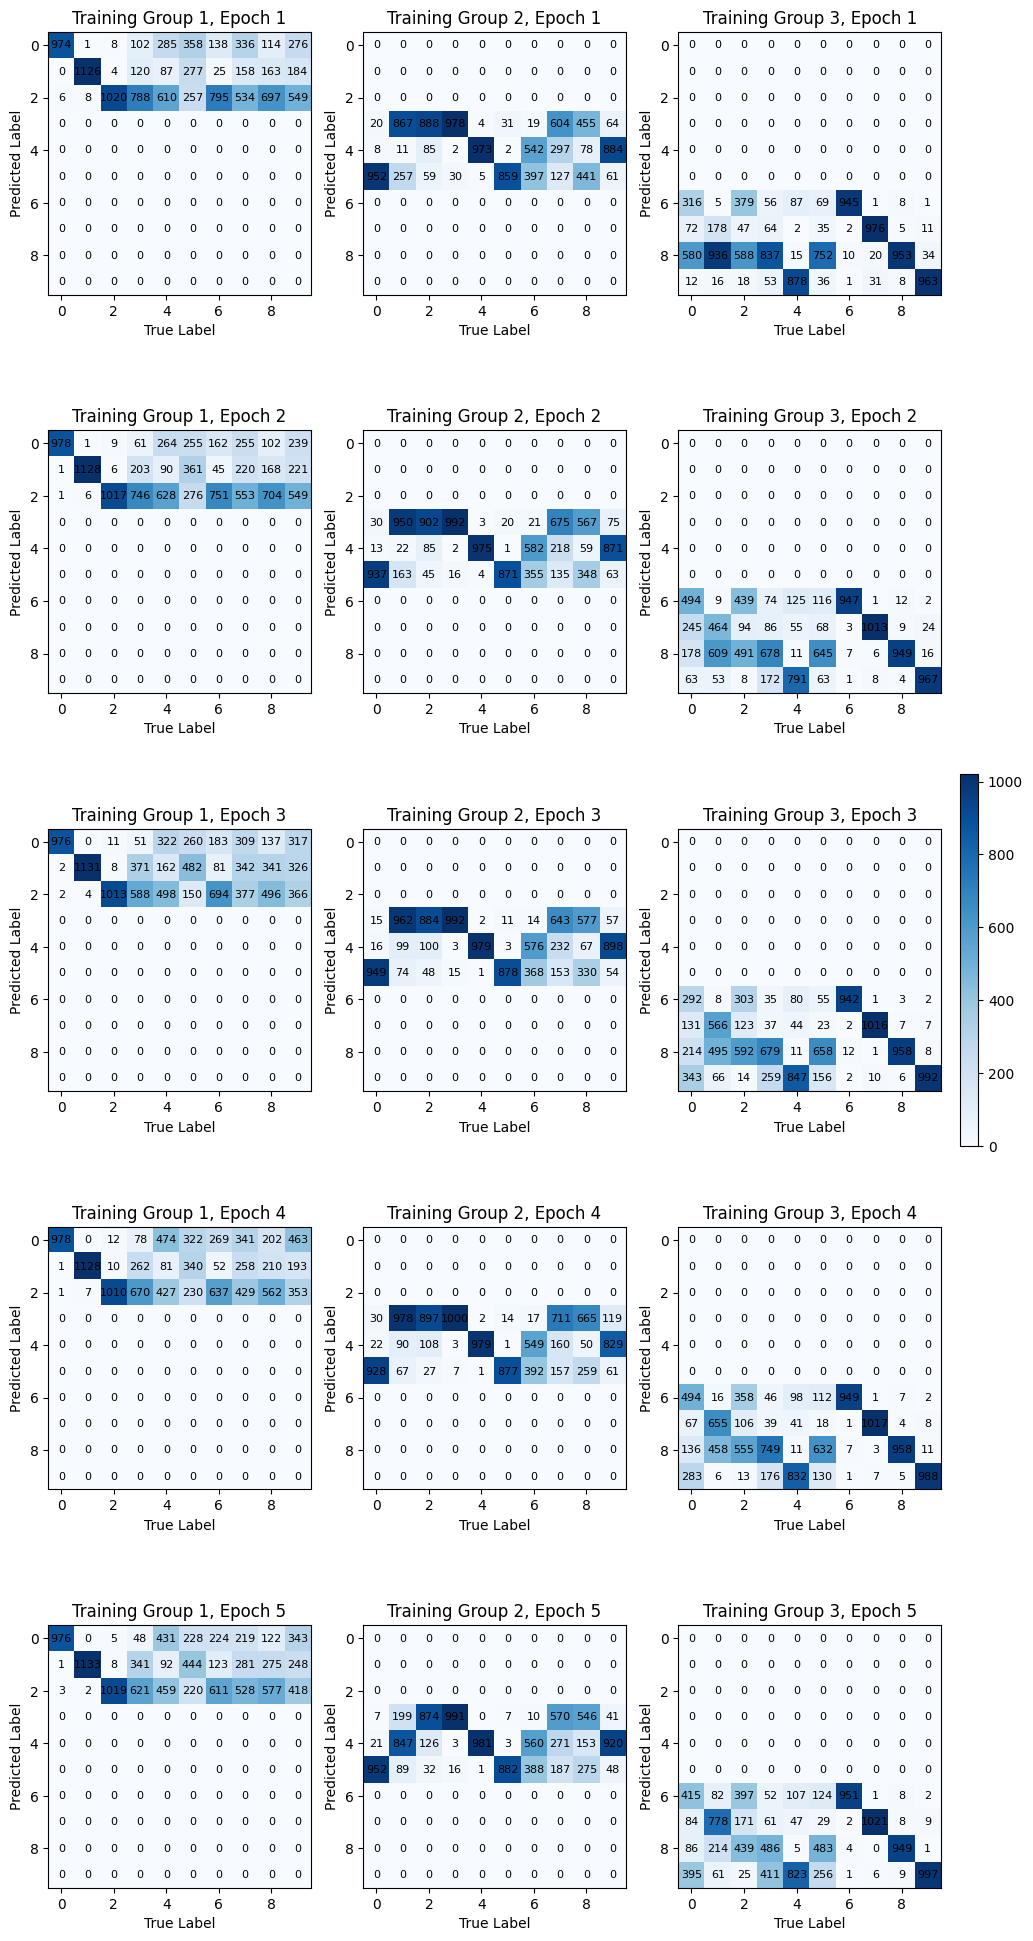

In [93]:
plot_cms(cm_group_set)

### PCA Analyses of Penultimate Layer

In [75]:
μ_cgm, σ_cgm = monte_carlo_cgm(dim_subspace=64, dim_space=64, n_samples=100_000, seed=42)

In [76]:
print(μ_cgm, σ_cgm)

0.10012655802435705 0.074830958688199


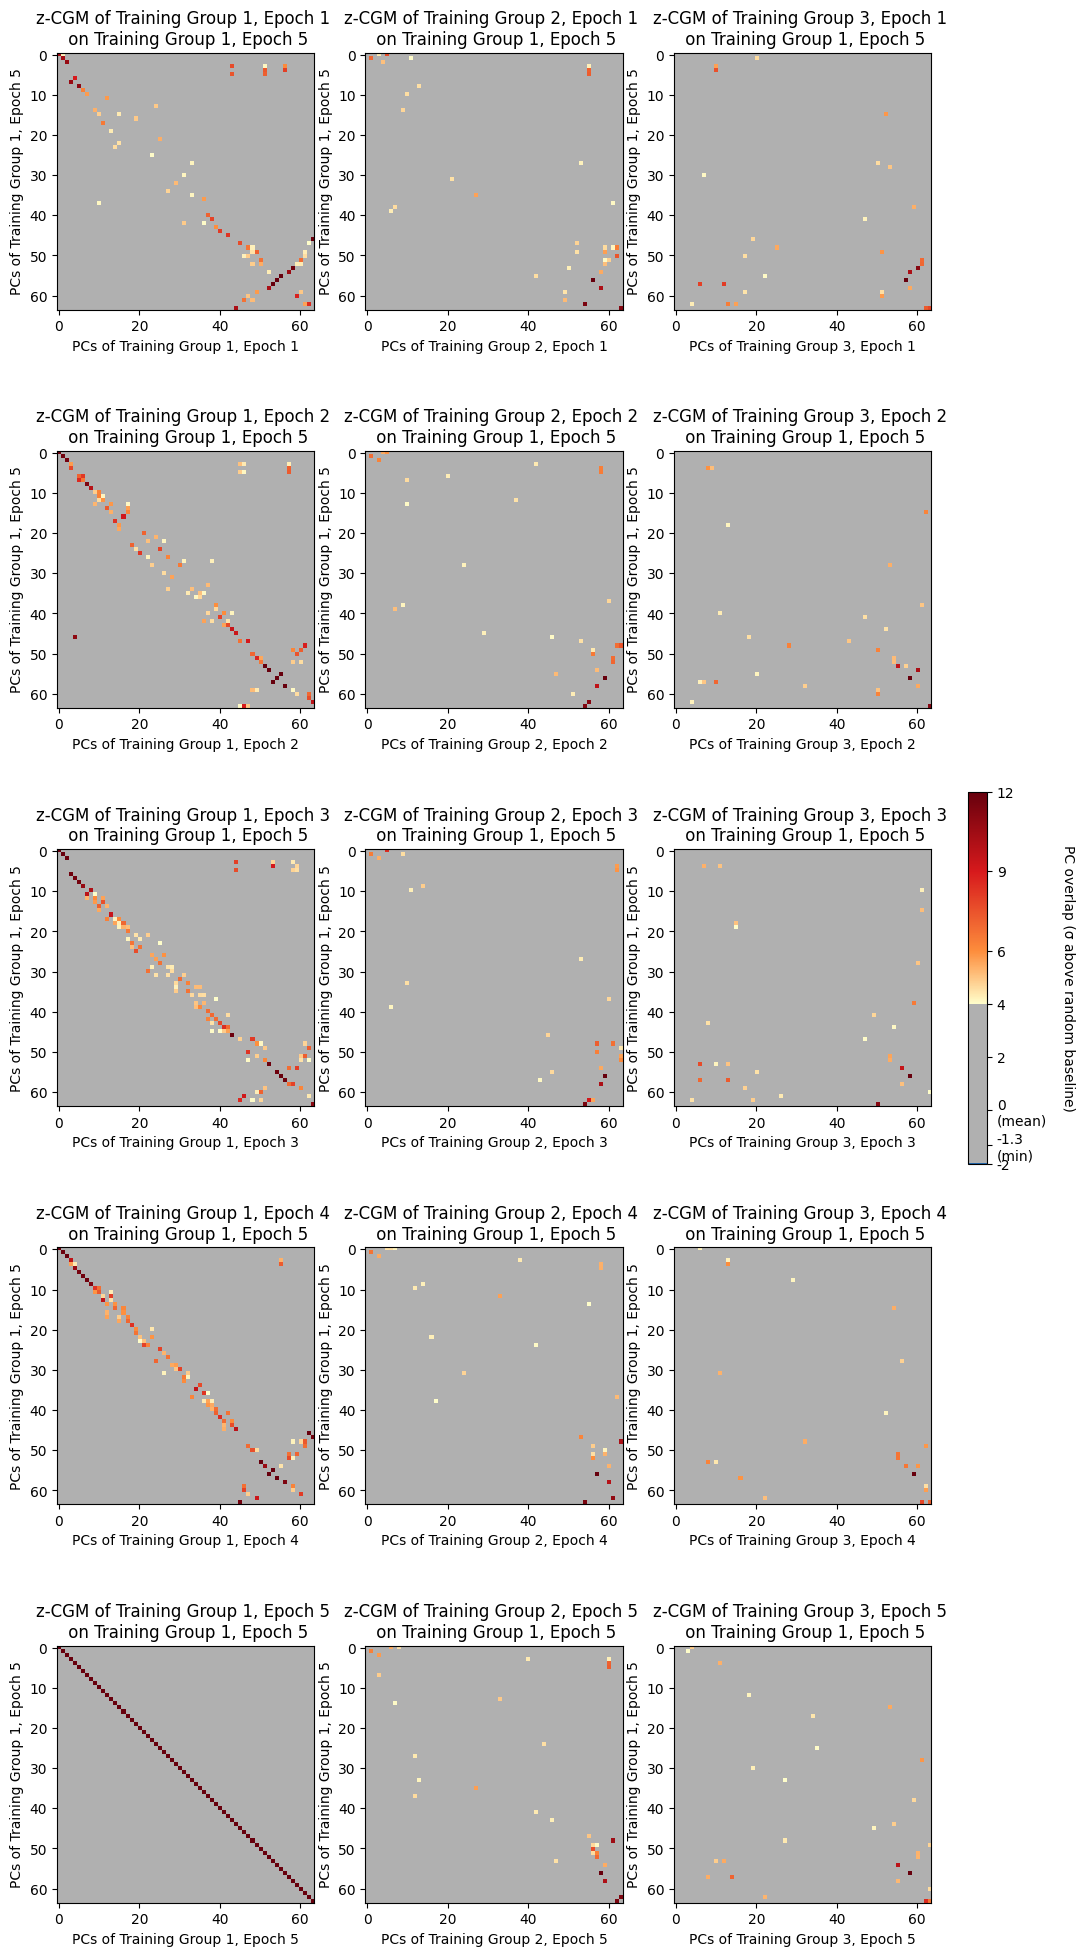

In [82]:
plot_pcas(pca_group_set, μ_cgm, σ_cgm, diagonalize=False)

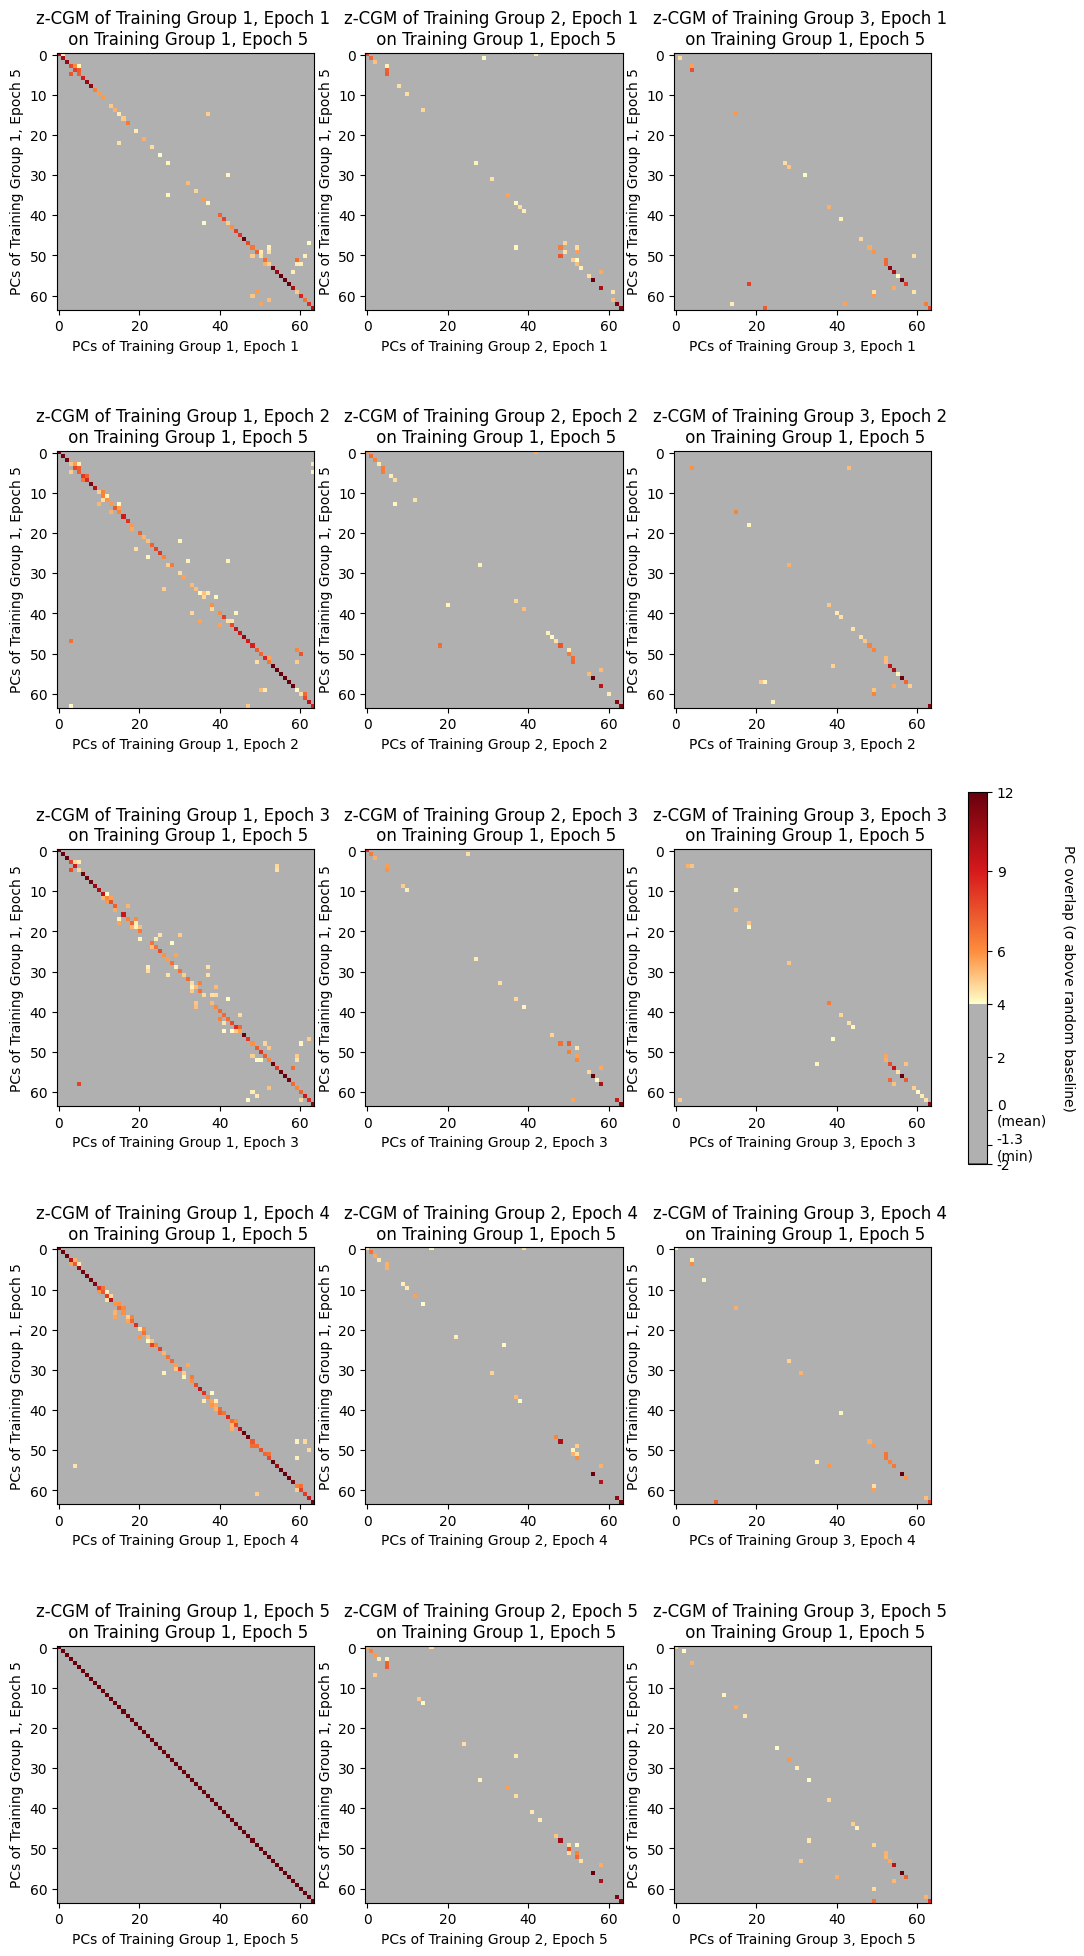

In [83]:
plot_pcas(pca_group_set, μ_cgm, σ_cgm, diagonalize=True)

### Control Plot

In [97]:
rng = np.random.default_rng(seed=42)
 
U = rng.standard_normal((64, 64)) 
V = rng.standard_normal((64, 64))        

U, _ = np.linalg.qr(U)                                                   
V, _ = np.linalg.qr(V)                                                   

cgm = np.abs(np.einsum("di, dj -> ij", U, V))        

c_cgm = (cgm - μ_cgm)/σ_cgm

In [98]:
U.shape, V.shape

((64, 64), (64, 64))

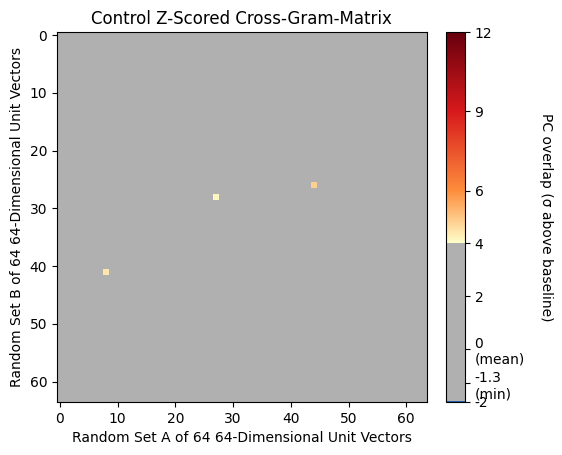

In [99]:
cgm_cmap, cgm_norm = make_cgm_colormap(
                                            vmin=-2,
                                            vmax=12,
                                            neutral_low=-2,     
                                            neutral_high=4    
                                        )
 
CGM_TICKS  = [-2, -1.3,         0,              2,        4,        6,        9,       12]
CGM_LABELS = ['-2', '-1.3\n(min)', '0\n(mean)', '2', '4', '6', '9', '12']

fig = plt.figure()

im = plt.imshow(c_cgm, cmap=cgm_cmap, norm=cgm_norm)
cbar = plt.colorbar(im, ticks=CGM_TICKS, fraction=0.05, pad=0.04)
cbar.ax.set_yticklabels(CGM_LABELS)
cbar.set_label("PC overlap (σ above baseline)", rotation=270, labelpad=20)

plt.title(f"Control Z-Scored Cross-Gram-Matrix")
plt.xlabel(f"Random Set A of 64 64-Dimensional Unit Vectors")
plt.ylabel(f"Random Set B of 64 64-Dimensional Unit Vectors")

plt.show()

### Computing Grassmannian Distance

In [95]:
subspace_size = 32

In [96]:
μ_gdist, σ_gdist = compute_random_baseline_gdist(dim_space=64, dim_subspace=subspace_size, n_samples=100_000, seed=42)

In [97]:
print(μ_gdist, σ_gdist)

5.1473454517720665 0.07463969700719873


In [98]:
gdist_set = []

In [99]:
flattened_pca_set = np.reshape(pca_group_set, (-1))

for i in range(len(flattened_pca_set)-1):

    pca_A = flattened_pca_set[num_epochs-1].components_[:subspace_size] #(dim_subspace, dim_space)
    pca_B = flattened_pca_set[i].components_[:subspace_size] #(dim_subspace, dim_space)

    U = np.transpose(pca_A) #(dim_space, dim_subspace)
    V = np.transpose(pca_B) #(dim_space, dim_subspace)

    M = np.einsum("ij, ik->jk", U, V)
    sigma = np.linalg.svd(M, compute_uv=False)
    sigma = np.clip(sigma, -1, 1)

    pangles = np.arccos(sigma)

    gdist = np.linalg.norm(pangles)

    gdist_set.append(gdist)

In [100]:
z_gdist_set = []

In [101]:
for gdist in gdist_set:

    z_gdist = (gdist-μ_gdist)/σ_gdist

    z_gdist_set.append(z_gdist)

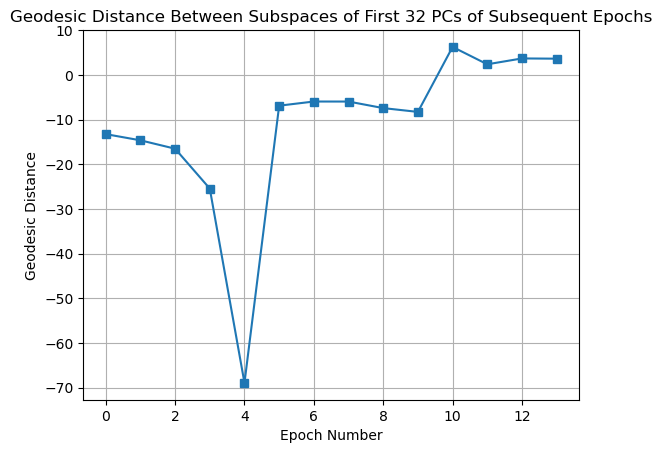

In [102]:
plt.figure()

plt.plot([epoch for epoch in range(len(flattened_pca_set)-1)], z_gdist_set, marker = "s")
plt.title(f"Geodesic Distance Between Subspaces of First {subspace_size} PCs of Subsequent Epochs")
plt.xlabel(f"Epoch Number")
plt.ylabel(f"Geodesic Distance")
plt.grid(True)